# Titanic
**Goal:** Predict passenger survival using feature engineering and machine learning.

**Structure:**
1. Imports & Setup
2. Load Data
3. Exploratory Data Analysis (EDA)
4. Preprocessing / Feature Engineering
5. Creating the model


## 1. Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, accuracy_score, f1_score, roc_auc_score
from sklearn.model_selection import StratifiedKFold, cross_validate, GridSearchCV, cross_val_predict

warnings.filterwarnings('ignore')

# Style
sns.set_style('whitegrid')
sns.set_palette('Set2')
plt.rcParams['font.size'] = 12
plt.rcParams['figure.facecolor'] = 'white'

PALETTE = ['#e74c3c', '#3498db']
SURVIVED_LABELS = {0: 'Died', 1: 'Survived'}


## 2. Load Data

In [2]:
df = pd.read_csv('train.csv')
df_raw = df.copy()

test_df = pd.read_csv('test.csv')

print(f'Dataset shape: {df.shape[0]} passengers, {df.shape[1]} columns')
print(f'Overall survival rate: {df["Survived"].mean():.1%}')
print(f'\nData types:')
print(df.dtypes)
df.head()


Dataset shape: 891 passengers, 12 columns
Overall survival rate: 38.4%

Data types:
PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
print('Basic statistics:')
df.describe()

Basic statistics:


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


          Missing Count  Missing %
Cabin               687       77.1
Age                 177       19.9
Embarked              2        0.2


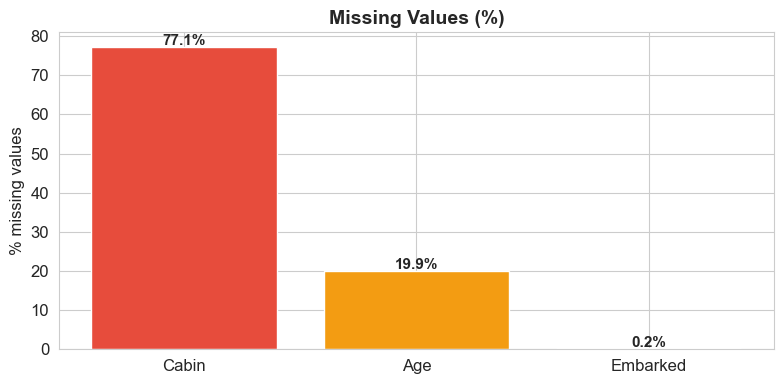

In [4]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
}).query('`Missing Count` > 0').sort_values('Missing Count', ascending=False)

print(missing_df)

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(missing_df.index, missing_df['Missing %'], color=['#e74c3c', '#f39c12', '#3498db'])
ax.set_title('Missing Values (%)', fontsize=14, fontweight='bold')
ax.set_ylabel('% missing values')
for bar, pct in zip(bars, missing_df['Missing %']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{pct}%', ha='center', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()


**Note:** `Cabin` has 77% missing values — instead of filling them, I'll create a binary feature called 'HasCabin'. `Age` has ~20% missing values, so I'll use the median value for the title to fill them. `Embarked` has only 2 missing values—I'll fill them with the mode.

## 3. Exploratory Data Analysis (EDA)

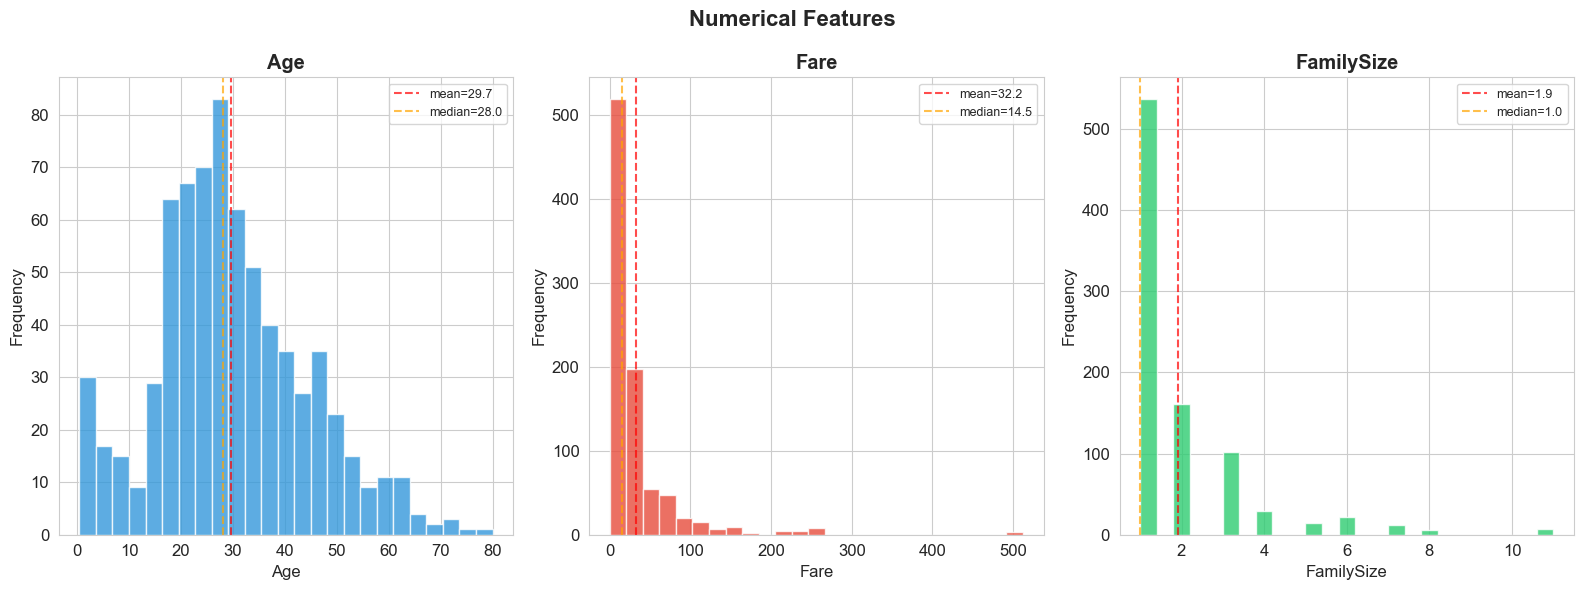

In [5]:
# Create Family size
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle('Numerical Features', fontsize=16, fontweight='bold')

numerical = ['Age', 'Fare', 'FamilySize']
colors = ['#3498db', '#e74c3c', '#2ecc71']

for ax, col, color in zip(axes.flatten(), numerical, colors):
    df[col].hist(bins=25, color=color, alpha=0.8, ax=ax, edgecolor='white')
    ax.set_title(f'{col}', fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency')
    ax.axvline(df[col].mean(), color='red', linestyle='--', alpha=0.7, label=f'mean={df[col].mean():.1f}')
    ax.axvline(df[col].median(), color='orange', linestyle='--', alpha=0.7, label=f'median={df[col].median():.1f}')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()


**Note:** Most passengers were adults, with an average age between 25 and 30 years old. Most purchased tickets at the lowest price. The median of `FamilySize` is 1, meaning most passengers were traveling alone.

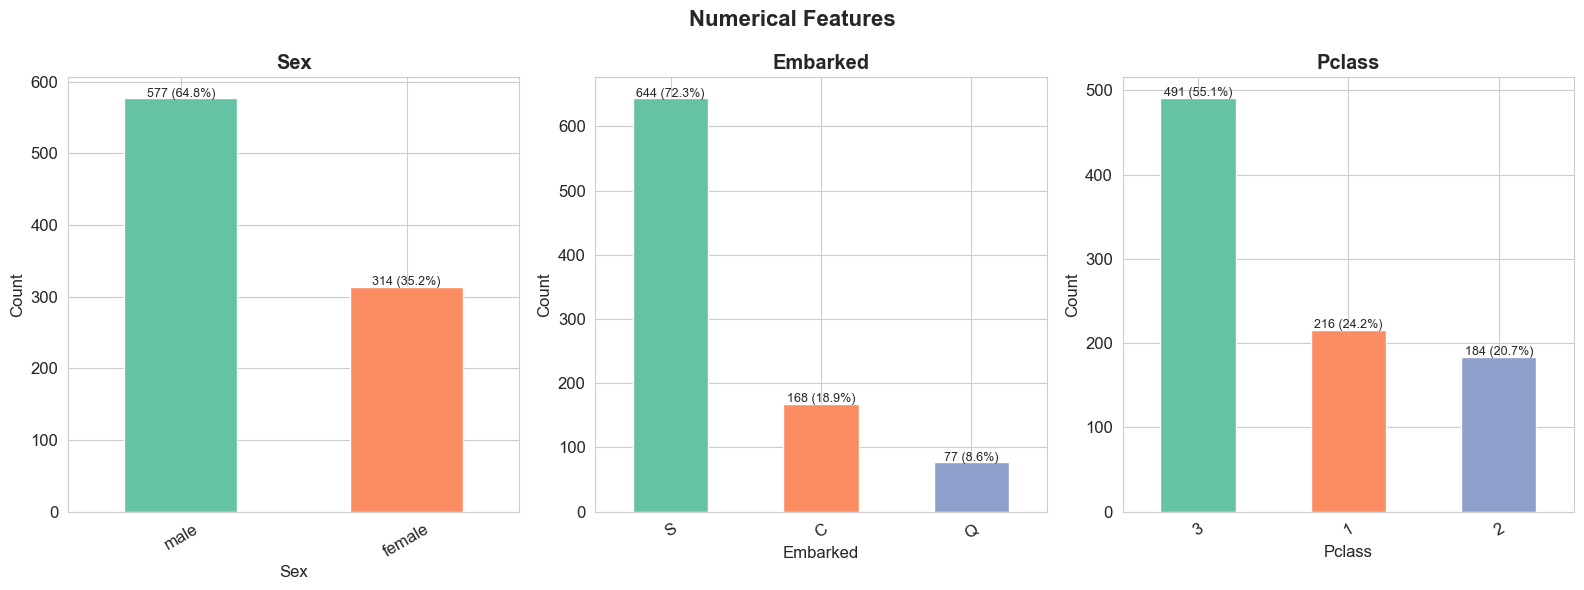

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle('Numerical Features', fontsize=16, fontweight='bold')

categorical = ['Sex', 'Embarked', 'Pclass']

for ax, col in zip(axes.flatten(), categorical):
    counts = df[col].value_counts()
    counts.plot(kind='bar', ax=ax, color=sns.color_palette('Set2', len(counts)), edgecolor='white', rot=30)
    ax.set_title(f'{col}', fontweight='bold')
    ax.set_ylabel('Count')
    total = len(df)
    for p in ax.patches:
        height = p.get_height()
        pct = height / total * 100
        ax.annotate(f'{int(height)} ({pct:.1f}%)',
            (p.get_x() + p.get_width()/2, height + 2),
            ha='center', fontsize=9)

plt.tight_layout()
plt.show()


**Note:** ~65% of passengers are male. Third class makes up ~55% of all passengers. Most boarded at Southampton.

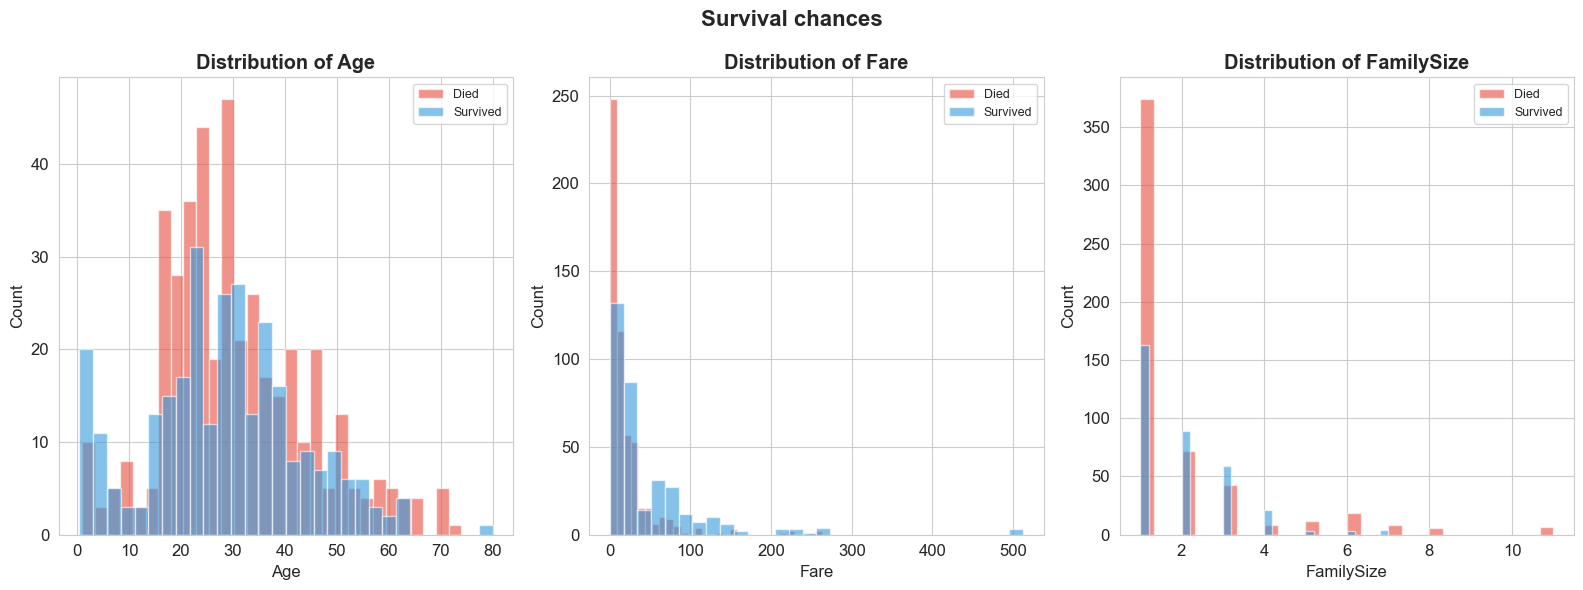

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle('Survival chances', fontsize=16, fontweight='bold')
for ax, col in zip(axes, ['Age', 'Fare', 'FamilySize']):
    for survived, color in enumerate(PALETTE):
        df[df['Survived'] == survived][col].hist(
            bins=30, alpha=0.6, color=color, label=SURVIVED_LABELS[survived], ax=ax)
    ax.set_title(f'Distribution of {col}', fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')
    ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

**Note:** The survival rate among children is significantly higher. `Fare`: The average ticket for survivors was significantly more expensive—wealthy passengers had priority access to lifeboats. `FamilySize`: Small families (2–4) survived better than individuals and larger groups.

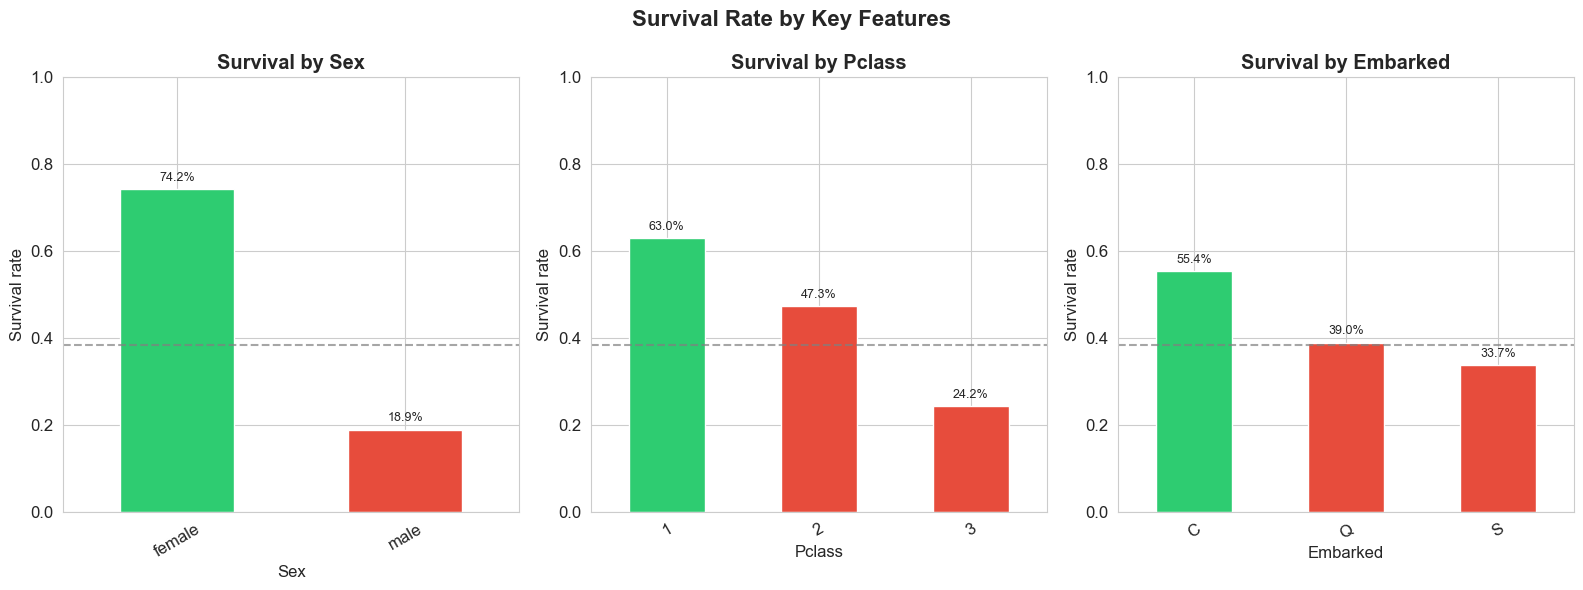

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle('Survival Rate by Key Features', fontsize=16, fontweight='bold')

cat_features = ['Sex', 'Pclass', 'Embarked']

for ax, col in zip(axes.flatten(), cat_features):
    survival = df.groupby(col)['Survived'].mean().sort_values(ascending=False)
    colors_bar = ['#2ecc71' if v > 0.5 else '#e74c3c' for v in survival.values]
    survival.plot(kind='bar', ax=ax, color=colors_bar, edgecolor='white', rot=30)
    ax.set_title(f'Survival by {col}', fontweight='bold')
    ax.set_ylim(0, 1)
    ax.axhline(df['Survived'].mean(), color='gray', linestyle='--', alpha=0.7, label='Mean')
    ax.set_ylabel('Survival rate')
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.1%}', (p.get_x() + p.get_width()/2, p.get_height() + 0.02),
                    ha='center', fontsize=9)

plt.tight_layout()
plt.show()


**Note:** Gender is the strongest predictor: female survival (~74%) vs. male survival (~19%). 1st class (~63%) vs. 3rd class (~24%). More survivors were found on Cherbourg.

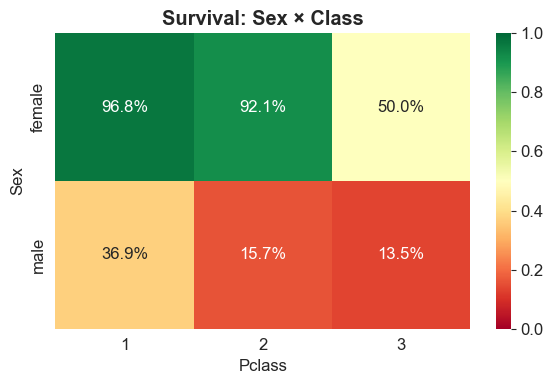

In [9]:
# Heatmap: Sex x Pclass
pivot = df.pivot_table('Survived', 'Sex', 'Pclass')

plt.figure(figsize=(6, 4))
sns.heatmap(pivot, annot=True, fmt='.1%', cmap='RdYlGn', vmin=0, vmax=1)

plt.title('Survival: Sex × Class', fontweight='bold')
plt.tight_layout()
plt.show()


**Note:** There is a strong correlation between `Sex` and `Pclass`. Women in the first group survived approximately 97% of the time—a virtually guaranteed survival. Only 14% of men in the third class survived.

## 4. Preprocessing / Feature Engineering

In [10]:
df.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
FamilySize       0
dtype: int64

In [11]:
df = df_raw

# Title
df['Title'] = df['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)

print('Title distribution and survival rate:')
title_stats = df.groupby('Title').agg(
    Count=('Survived', 'count'),
    Survived=('Survived', 'mean')
).sort_values('Count', ascending=False)
print(title_stats.to_string())

df['Title'] = df['Title'].replace({
    'Mlle': 'Miss', 'Ms': 'Miss', 'Mme': 'Mrs'
})
rare_titles = ['Lady', 'Countess', 'Capt', 'Col', 'Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer']
df['Title'] = df['Title'].replace(rare_titles, 'Rare')

# Fill Age
df['Age'] = df.groupby('Title')['Age'].transform(lambda x: x.fillna(x.median()))

# Family category
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

def family_category(size):
    if size == 1:
        return 'Alone'
    elif size <= 4:
        return 'Small'
    else:
        return 'Large'

df['FamilyCategory'] = df['FamilySize'].apply(family_category)

# Fill Embarked
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# Fare bins
df['FareBin'] = pd.qcut(df['Fare'], 4, labels=['Cheap', 'Medium', 'Expensive', 'Luxury'])

# Age bins
df['AgeBin'] = pd.cut(df['Age'], bins=[0, 12, 18, 30, 45, 60, 80],
                      labels=['Child', 'Teen', 'Young Adult', 'Adult', 'Middle Age', 'Senior'])

df['HasCabin'] = df['Cabin'].notna().astype(int)
df['Cabin'] = df['Cabin'].fillna('Unknown')

df['SexPclass'] = df['Sex'] + '_' + df['Pclass'].astype(str)


print(f'\nAfter cleaning: {df.shape[0]} rows, {df.shape[1]} features')
print(f'Missing values: {df.isnull().sum().sum()}')

Title distribution and survival rate:
          Count  Survived
Title                    
Mr          517  0.156673
Miss        182  0.697802
Mrs         125  0.792000
Master       40  0.575000
Dr            7  0.428571
Rev           6  0.000000
Major         2  0.500000
Col           2  0.500000
Mlle          2  1.000000
Mme           1  1.000000
Ms            1  1.000000
Capt          1  0.000000
Lady          1  1.000000
Jonkheer      1  0.000000
Don           1  0.000000
Countess      1  1.000000
Sir           1  1.000000

After cleaning: 891 rows, 19 features
Missing values: 0


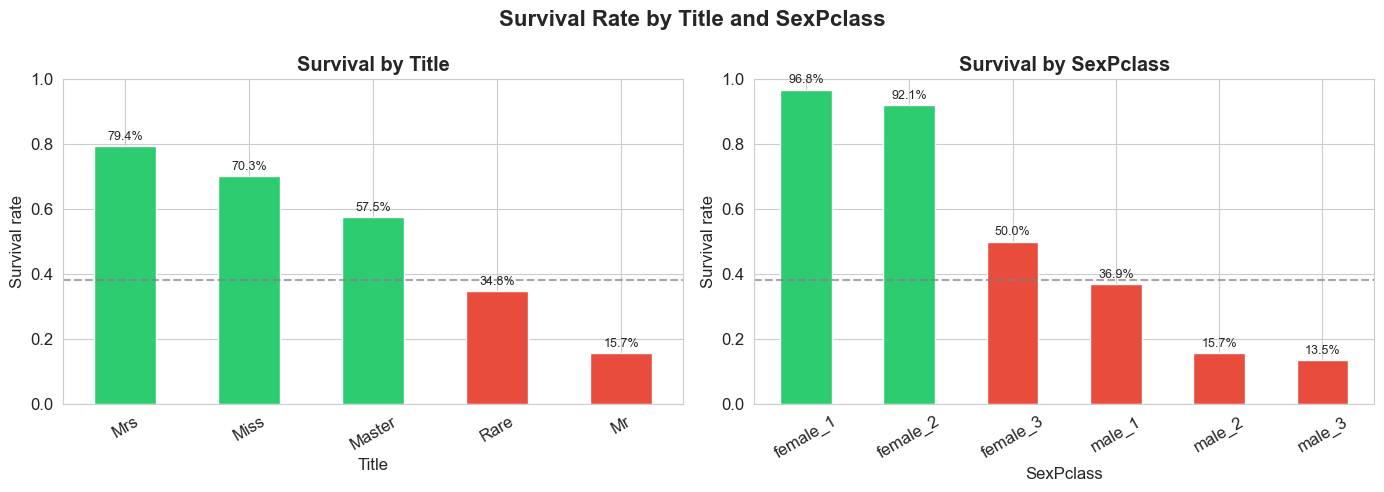

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Survival Rate by Title and SexPclass', fontsize=16, fontweight='bold')

for ax, col in zip(axes, ['Title', 'SexPclass']):
    survival = df.groupby(col)['Survived'].mean().sort_values(ascending=False)
    colors_bar = ['#2ecc71' if v > 0.5 else '#e74c3c' for v in survival.values]
    survival.plot(kind='bar', ax=ax, color=colors_bar, edgecolor='white', rot=30)
    ax.set_title(f'Survival by {col}', fontweight='bold')
    ax.set_ylim(0, 1)
    ax.axhline(df['Survived'].mean(), color='gray', linestyle='--', alpha=0.7, label='Mean')
    ax.set_ylabel('Survival rate')
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.1%}', (p.get_x() + p.get_width()/2, p.get_height() + 0.02),
                    ha='center', fontsize=9)
plt.tight_layout()
plt.show()

**Note:** Women holding the titles of `Mrs` and `Miss` have the highest survival rate (~79% and ~70%). For men holding the title of `Master` this rate is ~57%. Men holding the title of `Mister` have the lowest survival rate (~16%), with adult men being the last to board the lifeboats.

## 5. Creating the model

In [13]:
# Features
FEATURES = ['Pclass', 'Sex', 'Age', 'Fare', 'Embarked', 'FamilySize',
            'FamilyCategory', 'Title', 'FareBin', 'AgeBin', 'HasCabin', 'SexPclass']

# Encode categoricals
df_model = df[FEATURES + ['Survived']].copy()
cat_cols = ['Sex', 'Embarked', 'FamilyCategory', 'Title', 'FareBin', 'AgeBin', 'SexPclass']
le = LabelEncoder()
for col in cat_cols:
    df_model[col] = le.fit_transform(df_model[col].astype(str))

X = df_model[FEATURES]
y = df_model['Survived']


In [14]:
models = {
    'LogisticRegression': LogisticRegression(max_iter=1000, random_state=42),
    'RandomForest': RandomForestClassifier(n_estimators=300, max_depth=7,
                                           min_samples_split=4, min_samples_leaf=2,
                                           random_state=42, n_jobs=-1),
    'XGBoost': XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05,
                              subsample=0.8, colsample_bytree=0.8,
                              random_state=42, eval_metric='logloss', verbosity=0)
}

# Cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}
for name, model in models.items():
    scores = cross_validate(model, X, y, cv=cv,
                            scoring=['accuracy', 'f1', 'roc_auc'])
    results[name] = {
        'Accuracy': scores['test_accuracy'].mean(),
        'F1': scores['test_f1'].mean(),
        'ROC-AUC': scores['test_roc_auc'].mean()
    }

results_df = pd.DataFrame(results).T.sort_values('ROC-AUC', ascending=False)
print(results_df.round(4).to_string())

                    Accuracy      F1  ROC-AUC
XGBoost               0.8451  0.7876   0.8901
RandomForest          0.8361  0.7690   0.8844
LogisticRegression    0.8148  0.7543   0.8639


I trained three models using 5-fold cross-validation on the full training set — this gives a more honest performance estimate than a single train/test split, since every sample gets to be in the test fold exactly once.

| Model | Accuracy | F1 | ROC-AUC |
|---|---|---|---|
| XGBoost | 0.8451 | 0.7876 | 0.8901 |
| RandomForest | 0.8361 | 0.7690 | 0.8844 |
| LogisticRegression | 0.8148 | 0.7543 | 0.8639 |

XGBoost outperforms the other models across all metrics. Ensemble methods (XGBoost, RandomForest) handle non-linear relationships better than LogisticRegression on this dataset. A ROC-AUC of 0.89 means the model correctly ranks a survivor above a non-survivor 89% of the time.

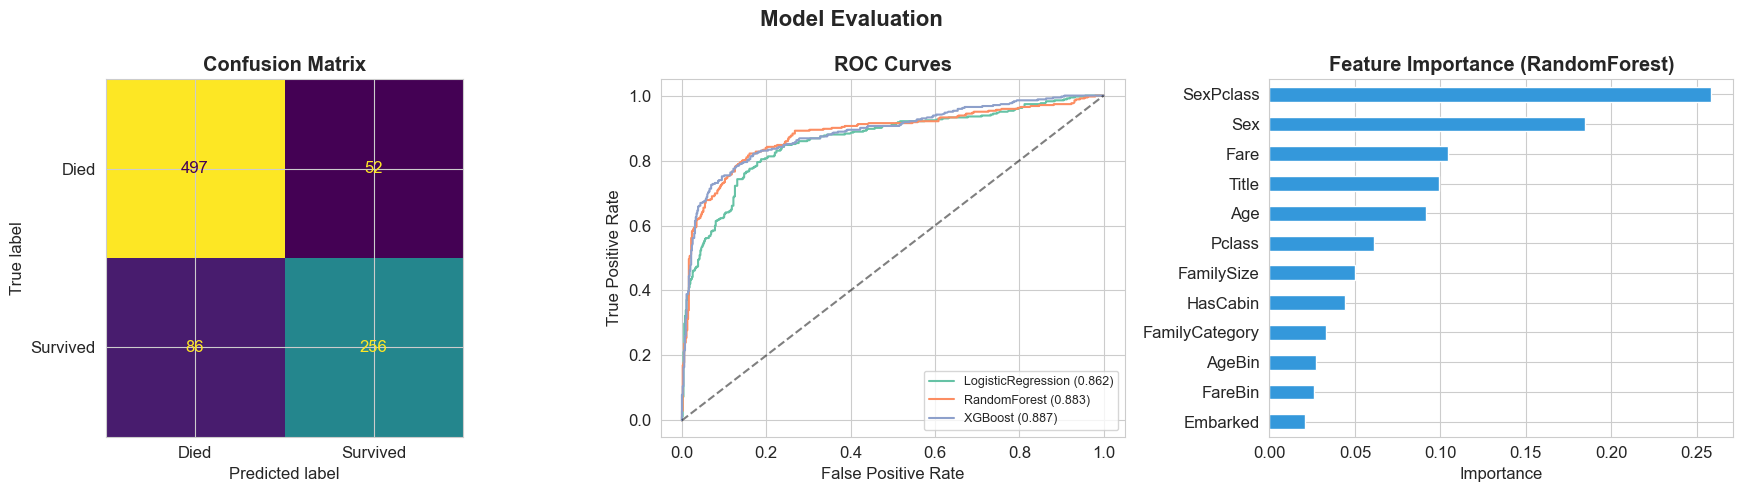

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Model Evaluation', fontsize=16, fontweight='bold')

best_model = models['XGBoost']
best_model.fit(X, y)

y_pred_cv = cross_val_predict(best_model, X, y, cv=cv)
y_proba_cv = cross_val_predict(best_model, X, y, cv=cv, method='predict_proba')[:, 1]

# Confusion matrix
cm = confusion_matrix(y, y_pred_cv)
ConfusionMatrixDisplay(cm, display_labels=['Died', 'Survived']).plot(ax=axes[0], colorbar=False)
axes[0].set_title('Confusion Matrix', fontweight='bold')

# ROC curves
for name, model in models.items():
    model.fit(X, y)
    y_proba_model = cross_val_predict(model, X, y, cv=cv, method='predict_proba')[:, 1]
    fpr, tpr, _ = roc_curve(y, y_proba_model)
    auc = roc_auc_score(y, y_proba_model)
    axes[1].plot(fpr, tpr, label=f'{name} ({auc:.3f})')
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.5)
axes[1].set_title('ROC Curves', fontweight='bold')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend(fontsize=9)

# Feature importance (RandomForest)
importances = pd.Series(
    models['RandomForest'].feature_importances_,
    index=FEATURES
).sort_values(ascending=True)
importances.plot(kind='barh', ax=axes[2], color='#3498db', edgecolor='white')
axes[2].set_title('Feature Importance (RandomForest)', fontweight='bold')
axes[2].set_xlabel('Importance')

plt.tight_layout()
plt.show()

In [16]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 4, 5],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 1.0],
}

grid_search = GridSearchCV(
    XGBClassifier(random_state=42, eval_metric='logloss', verbosity=0),
    param_grid,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1
)
grid_search.fit(X, y)

print(f'Best params: {grid_search.best_params_}')
print(f'Best ROC-AUC (CV): {grid_search.best_score_:.4f}')

Best params: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100, 'subsample': 0.8}
Best ROC-AUC (CV): 0.8904


XGBoost tuning yielded minimal improvement (+0.0003 ROC-AUC) — the model was already near-optimal with default parameters. Best params: learning_rate=0.1, max_depth=5, n_estimators=100, subsample=0.8.